In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import openai
from sand_bob._code_gen import generate_run_check

In [2]:
num_iterations = 25

In [3]:
def contains_yes(text):
    return "yes" in text

In [4]:
res = generate_run_check("Write Python code that adds 7 and 5 and prints out the result only.", expected_output="12")
res

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 1109 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=10.144294500350952, container_id='90d525333ee43b314525277ce6a074d527eef8ca9d11ad53de21d4afdc9e12d7', code='# Compute the sum of 7 and 5\nresult = 7 + 5\n\n# Show the result (only this output will appear)\ndisplay(result)', dependencies=[], traceback=None, files={'/display_output/notebook_executed.ipynb': b'{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": 1,\n   "metadata": {\n    "execution": {\n     "iopub.execute_input": "2025-08-08T10:34:45.440858Z",\n     "iopub.status.busy": "2025-08-08T10:34:45.440615Z",\n     "iopub.status.idle": "2025-08-08T10:34:45.449316Z",\n     "shell.execute_reply": "2025-08-08T10:34:45.448588Z"\n    }\n   },\n   "outputs": [\n    {\n     "data": {\n      "text/plain": [\n       "12"\n      ]\n     },\n     "metadata": {},\n     "output_type": "display_data"\n    }\n   ],\n   "source": [\n    "# Compute the sum of 7 and 5\\n",\n    "result = 7 + 5\\n",\n    "\\n",\n    "# Show the result (only this output will appear)\\n",\n    "display(result)\\n"\n   ]\n  }\n ],\n "metadata": {\n  "kernelspec": {\n   "display_name": "Python 3",\n   "language": "python",\n   "name": "python3"\n  },\n  "language_info": {\n   "codemirror_mode": {\n    "name": "ipython",\n    "version": 3\n   },\n   "file_extension": ".py",\n   "mimetype": "text/x-python",\n   "name": "python",\n   "nbconvert_exporter": "python",\n   "pygments_lexer": "ipython3",\n   "version": "3.11.13"\n  }\n },\n "nbformat": 4,\n "nbformat_minor": 4\n}\n'}, n_attempts=1, result_check_ok=False, outputs=[{'type': 'text/plain', 'data': '12'}])

In [5]:
generate_run_check("""Write Python code that loads the file /input_data/data.csv, 
determmines if columns 'A' and 'B' are significantly different and 
prints out 'yes' in case the p-value < 0.05 and 'not sure' otherwise.""", 
dependencies=["pandas", "scipy"], 
input_host_path="./input_data",
expected_output="not sure")

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 2041 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=45.40753149986267, container_id='8800a01693724cf0bb2da5ff355eb9dbdf02a69a0c053727277da48e5edbed05', code='import pandas as pd\nfrom scipy import stats\n\n# Load the data\ndf = pd.read_csv("/input_data/data.csv")\n\n# Make sure the required columns exist\nif not {"A", "B"}.issubset(df.columns):\n    raise ValueError("Columns \'A\' and \'B\' must both be present in the CSV file.")\n\n# Drop missing values in the two columns (paired test assumes same length)\ndata_a = df["A"].dropna()\ndata_b = df["B"].dropna()\n\n# Perform an independent two‑sample t‑test\n# (if the measurements are paired you could use stats.ttest_rel instead)\nt_stat, p_val = stats.ttest_ind(data_a, data_b, equal_var=False)\n\n# Show the computed p‑value\ndisplay(p_val)\n\n# Print the decision\nif p_val < 0.05:\n    print("yes")\nelse:\n    print("not sure")', dependencies=['pandas', 'scipy'], traceback=None, files={'/display_output/notebook_executed.ipynb': b'{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": 1,\n   "metadata": {\n    "execution": {\n     "iopub.execute_input": "2025-08-08T10:35:32.260332Z",\n     "iopub.status.busy": "2025-08-08T10:35:32.260133Z",\n     "iopub.status.idle": "2025-08-08T10:35:32.955910Z",\n     "shell.execute_reply": "2025-08-08T10:35:32.955343Z"\n    }\n   },\n   "outputs": [\n    {\n     "data": {\n      "text/plain": [\n       "np.float64(0.1842825236592218)"\n      ]\n     },\n     "metadata": {},\n     "output_type": "display_data"\n    },\n    {\n     "name": "stdout",\n     "output_type": "stream",\n     "text": [\n      "not sure\\n"\n     ]\n    }\n   ],\n   "source": [\n    "import pandas as pd\\n",\n    "from scipy import stats\\n",\n    "\\n",\n    "# Load the data\\n",\n    "df = pd.read_csv(\\"/input_data/data.csv\\")\\n",\n    "\\n",\n    "# Make sure the required columns exist\\n",\n    "if not {\\"A\\", \\"B\\"}.issubset(df.columns):\\n",\n    "    raise ValueError(\\"Columns \'A\' and \'B\' must both be present in the CSV file.\\")\\n",\n    "\\n",\n    "# Drop missing values in the two columns (paired test assumes same length)\\n",\n    "data_a = df[\\"A\\"].dropna()\\n",\n    "data_b = df[\\"B\\"].dropna()\\n",\n    "\\n",\n    "# Perform an independent two\xe2\x80\x91sample t\xe2\x80\x91test\\n",\n    "# (if the measurements are paired you could use stats.ttest_rel instead)\\n",\n    "t_stat, p_val = stats.ttest_ind(data_a, data_b, equal_var=False)\\n",\n    "\\n",\n    "# Show the computed p\xe2\x80\x91value\\n",\n    "display(p_val)\\n",\n    "\\n",\n    "# Print the decision\\n",\n    "if p_val < 0.05:\\n",\n    "    print(\\"yes\\")\\n",\n    "else:\\n",\n    "    print(\\"not sure\\")\\n"\n   ]\n  }\n ],\n "metadata": {\n  "kernelspec": {\n   "display_name": "Python 3",\n   "language": "python",\n   "name": "python3"\n  },\n  "language_info": {\n   "codemirror_mode": {\n    "name": "ipython",\n    "version": 3\n   },\n   "file_extension": ".py",\n   "mimetype": "text/x-python",\n   "name": "python",\n   "nbconvert_exporter": "python",\n   "pygments_lexer": "ipython3",\n   "version": "3.11.13"\n  }\n },\n "nbformat": 4,\n "nbformat_minor": 4\n}\n'}, n_attempts=1, result_check_ok=False, outputs=[{'type': 'text/plain', 'data': 'np.float64(0.1842825236592218)'}, {'type': 'text/plain', 'data': 'not sure\n'}])

In [6]:
# decorator to run a function n times
def iter(func, n=1, *args, **kwargs):
    from tqdm import tqdm
    results = []
    for _ in tqdm(range(n)):
        results.append(func(*args, **kwargs))
    return results


res1 = iter(generate_run_check, n=num_iterations, prompt="""
Write Python code that loads the file /input_data/data.csv, 
determmines if columns 'A' and 'B' are significantly different and 
prints out 'yes' in case the p-value < 0.05 and 'not sure' otherwise.""", 
dependencies=["pandas", "scipy"], 
input_host_path="./input_data",
expected_output=contains_yes)

[r.result_check_ok for r in res1]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [08:58<00:00, 21.53s/it]


[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

In [7]:
print(res1[0].traceback)

None


In [8]:
res2 = iter(generate_run_check, n=num_iterations, prompt="""
You are an excellent statistician and python programmer. You always work according to good scientific practices.
           
Write Python code that loads the file /input_data/data.csv, 
determmines if columns 'A' and 'B' are significantly different and 
prints out 'yes' in case the p-value < 0.05 and 'not sure' otherwise.""", 
dependencies=["pandas", "scipy"], 
input_host_path="./input_data",
expected_output=contains_yes)

[r.result_check_ok for r in res2]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [09:15<00:00, 22.23s/it]


[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

In [9]:
res3 = iter(generate_run_check, n=num_iterations, prompt="""
You are an excellent statistician and python programmer. You always work according to good scientific practices.
When applying statistical tests, you MUST always check the assumptions of the tests before deciding on the test to apply.
           
Write Python code that loads the file /input_data/data.csv, 
determmines if columns 'A' and 'B' are significantly different and 
prints out 'yes' in case the p-value < 0.05 and 'not sure' otherwise.""", 
dependencies=["pandas", "scipy"], 
input_host_path="./input_data",
expected_output=contains_yes)

[r.result_check_ok for r in res3]

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [14:59<00:00, 35.98s/it]


[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

In [10]:
res3[0]

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 5034 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=16.38850498199463, container_id='6947f6d334075a84d33c6dcb6a4968ebc2f4ca9066106358ab211e3ad60cc0e4', code='import pandas as pd\nimport numpy as np\nfrom scipy import stats\n\n# ------------------------------------------------------------------\n# 1. Load the data\n# ------------------------------------------------------------------\ndf = pd.read_csv("/input_data/data.csv")\n\n# keep only the two columns of interest and drop missing values\ndata_a = df["A"].dropna()\ndata_b = df["B"].dropna()\n\n# ------------------------------------------------------------------\n# 2. Check the assumptions\n# ------------------------------------------------------------------\n# 2.1  Normality (Shapiro‑Wilk test) – applied to each sample separately\nshapiro_a = stats.shapiro(data_a)\nshapiro_b = stats.shapiro(data_b)\n\ndisplay({\n    "assumption": "normality (Shapiro‑Wilk)",\n    "A – statistic": shapiro_a.statistic,\n    "A – p‑value": shapiro_a.pvalue,\n    "B – statistic": shapiro_b.statistic,\n    "B – p‑value": shapiro_b.pvalue,\n})\n\nnorm_a = shapiro_a.pvalue > 0.05\nnorm_b = shapiro_b.pvalue > 0.05\n\n# 2.2  Equality of variances (Levene’s test) – only meaningful if both groups are approx. normal\nlevene = stats.levene(data_a, data_b)\ndisplay({\n    "assumption": "equal variances (Levene)",\n    "statistic": levene.statistic,\n    "p‑value": levene.pvalue,\n})\nequal_var = levene.pvalue > 0.05\n\n# ------------------------------------------------------------------\n# 3. Choose the appropriate statistical test\n# ------------------------------------------------------------------\nif norm_a and norm_b:\n    # both groups look normal → use (paired) t‑test\n    # If the rows correspond to paired observations you would use `stats.ttest_rel`.\n    # Here we assume they are independent samples.\n    t_res = stats.ttest_ind(data_a, data_b, equal_var=equal_var)\n    test_name = "Independent t‑test"\n    test_stat = t_res.statistic\n    p_val = t_res.pvalue\nelse:\n    # one or both groups deviate from normality → use Mann‑Whitney U test\n    u_res = stats.mannwhitneyu(data_a, data_b, alternative="two-sided")\n    test_name = "Mann‑Whitney U test"\n    test_stat = u_res.statistic\n    p_val = u_res.pvalue\n\n# ------------------------------------------------------------------\n# 4. Report the result\n# ------------------------------------------------------------------\ndisplay({\n    "test": test_name,\n    "test_statistic": test_stat,\n    "p_value": p_val,\n})\n\n# final decision according to the 0.05 significance level\nif p_val < 0.05:\n    print("yes")\nelse:\n    print("not sure")', dependencies=['pandas', 'scipy', 'statsmodels'], traceback=None, files={'/display_output/notebook_executed.ipynb': b'{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": 1,\n   "metadata": {\n    "execution": {\n     "iopub.execute_input": "2025-08-08T10:54:07.774971Z",\n     "iopub.status.busy": "2025-08-08T10:54:07.774770Z",\n     "iopub.status.idle": "2025-08-08T10:54:08.506288Z",\n     "shell.execute_reply": "2025-08-08T10:54:08.505691Z"\n    }\n   },\n   "outputs": [\n    {\n     "data": {\n      "text/plain": [\n       "{\'assumption\': \'normality (Shapiro\xe2\x80\x91Wilk)\',\\n",\n       " \'A \xe2\x80\x93 statistic\': np.float64(0.997215163326752),\\n",\n       " \'A \xe2\x80\x93 p\xe2\x80\x91value\': np.float64(0.5623557659711895),\\n",\n       " \'B \xe2\x80\x93 statistic\': np.float64(0.8937110073820878),\\n",\n       " \'B \xe2\x80\x93 p\xe2\x80\x91value\': np.float64(4.063512349586393e-18)}"\n      ]\n     },\n     "metadata": {},\n     "output_type": "display_data"\n    },\n    {\n     "data": {\n      "text/plain": [\n       "{\'assumption\': \'equal variances (Levene)\',\\n",\n       " \'statistic\': np.float64(80.671832812170

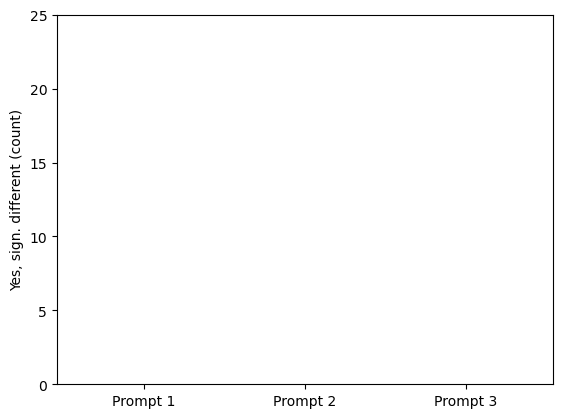

In [11]:
# Initialize counters
count_res1 = sum(1 for item in res1 if item.result_check_ok is True)
count_res2 = sum(1 for item in res2 if item.result_check_ok is True)
count_res3 = sum(1 for item in res3 if item.result_check_ok is True)

# Data for plotting
counts = [count_res1, count_res2, count_res3]
prompts = ["Prompt 1", "Prompt 2", "Prompt 3"]

# Plotting the bar graph
plt.bar(prompts, counts)
plt.ylabel('Yes, sign. different (count)')
plt.ylim((0, num_iterations))
plt.show()

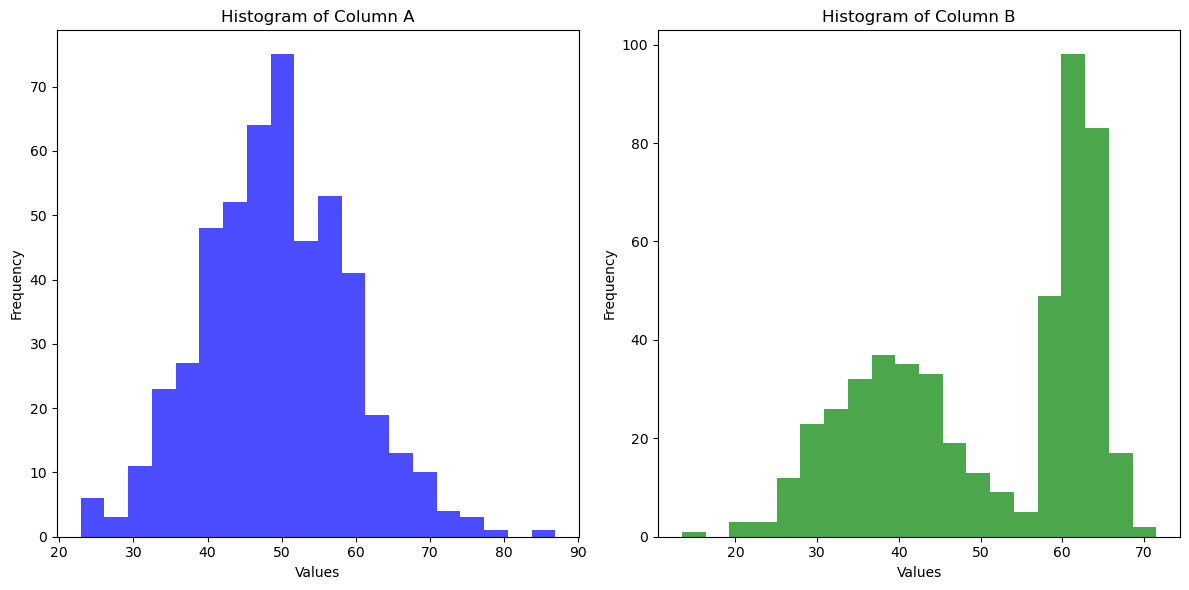

In [12]:


# Load the CSV file into a DataFrame
df = pd.read_csv('input_data/data.csv')

# Plot histograms for columns "A" and "B"
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['A'], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of Column A')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['B'], bins=20, color='green', alpha=0.7)
plt.title('Histogram of Column B')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()